# 04 — Model Training

Trains and evaluates models to predict comment persuasiveness on CMV.
Uses a thread-grouped train/test split to prevent data leakage.

Loads directly from `results/03_cmv_comments_df.csv.zip` — no need to re-run notebooks 01–03.

## Load data


In [3]:
import pandas as pd
import zipfile
import json

with zipfile.ZipFile('../results/03_cmv_comments_df.csv.zip') as z:
    comments_df = pd.read_csv(z.open(z.namelist()[0]))
comments_df = comments_df.copy()  # consolidate blocks - avoids a pandas PerformanceWarning on later single-column inserts

with open('../results/03_untrusted_features.json') as f:
    untrusted_features = json.load(f)

print(f'Loaded {len(comments_df)} rows, {comments_df.shape[1]} columns')
print(f'Untrusted features (excluded from the main model, tested separately below): {untrusted_features}')
comments_df.head(3)

Loaded 3971 rows, 237 columns
Untrusted features (excluded from the main model, tested separately below): ['sentiment_vader', 'tone_label', 'style_label', 'ethos_score', 'pathos_score', 'logos_score']


,original_post,thread_text,final_comment,is_convincing,final_comment_id,cleaned_final_comment,cleaned_thread_text,cleaned_original_post,sentiment_vader,sentiment_llm,...,logos_match,ethos_diff,pathos_diff,logos_diff,adj_adv_ratio_op,adj_adv_ratio_diff,fk_grade_level_op,fk_grade_level_diff,evidence_count_op,evidence_count_diff
0,CMV: Mike Bloomberg's campaign is proof that t...,"> But, as long as Corporate taxes are a thing ...",Δ You're completely [right](https://smallbusin...,0,fjlpe2a,Δ Youre completely righthttpssmallbusinesschro...,But as long as Corporate taxes are thing you...,CMV Mike Bloombergs campaign is proof that the...,0.9864,0.7,...,True,0.0,-0.3,0.2,1.857143,-1.593985,12.225014,-1.930014,5,-2
1,CMV: Mike Bloomberg's campaign is proof that t...,NaN,> money being taxed as profit for the company...,0,fjm1dyy,money being taxed as profit for the company ...,NaN,CMV Mike Bloombergs campaign is proof that the...,0.5505,-0.6,...,True,-0.1,0.0,0.0,1.857143,-1.057143,12.225014,-4.290426,5,-5
2,CMV: Mike Bloomberg's campaign is proof that t...,NaN,I saved your post it was so good. Hear hear to...,0,fjlcge6,saved your post it was so good Hear hear to that,NaN,CMV Mike Bloombergs campaign is proof that the...,0.7804,1.0,...,False,-0.3,0.4,-0.6,1.857143,-0.857143,12.225014,-13.675014,5,-5


## Add `thread_id`

Each Reddit thread can have many comments. A naive train/test split by comment row
allows comments from the same thread to appear on both sides — the model sees the
thread's writing style and topic during training and effectively 'recognises' it at
test time. This inflates performance artificially.

To fix this we split by thread, keeping all comments from a thread on the same side.
`thread_id` is a stable identifier for each thread, derived by hashing the
`original_post` text — which is identical for every comment in the same thread.


In [4]:
import hashlib

comments_df['thread_id'] = comments_df['original_post'].apply(
    lambda x: hashlib.md5(str(x).encode()).hexdigest()
)

print(f'Unique threads : {comments_df["thread_id"].nunique()}')
print(f'Total comments : {len(comments_df)}')
print(f'Avg comments per thread: {len(comments_df) / comments_df["thread_id"].nunique():.1f}')


Unique threads : 401
Total comments : 3971
Avg comments per thread: 9.9


## Split by thread, not by comment

Using `thread_id` as a grouping key, `GroupShuffleSplit` ensures every comment
from a given thread lands entirely in train or entirely in test — never both.


In [5]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder

# Comment-side, OP-side, and comment↔OP diff features from 03.1-03.3.
# fk_reading_ease has no _op/_diff counterpart - 03.3 section 7.7 dropped it as
# redundant with fk_grade_level_op (r=-0.905), so we keep it comment-side only.
numeric_features = [
    'sentiment_llm', 'adj_adv_ratio', 'fk_grade_level', 'fk_reading_ease', 'evidence_count',
    'ethos_llm', 'pathos_llm', 'logos_llm',
    'sentiment_llm_op', 'adj_adv_ratio_op', 'fk_grade_level_op', 'evidence_count_op',
    'ethos_llm_op', 'pathos_llm_op', 'logos_llm_op',
    'sentiment_diff', 'ethos_diff', 'pathos_diff', 'logos_diff',
    'adj_adv_ratio_diff', 'fk_grade_level_diff', 'evidence_count_diff',
]
embedding_features = [c for c in comments_df.columns if c.startswith('embedding_')]
label = 'is_convincing'

# Encode categorical tone features
categorical_features = ['tone_google', 'tone_google_op']
onehot_encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
tone_encoded = onehot_encoder.fit_transform(comments_df[categorical_features].fillna('unknown'))
tone_df = pd.DataFrame(tone_encoded, columns=onehot_encoder.get_feature_names_out(), index=comments_df.index)

# style_google/style_google_op (LLM-verified), not style_label/style_label_op -
# style_label is on untrusted_features (03.1: zero-shot formality labels didn't
# hold up under inspection), and it has no _op counterpart at all.
comments_df['is_formal']    = (comments_df['style_google']    == 'Formal').astype(int)
comments_df['is_formal_op'] = (comments_df['style_google_op'] == 'Formal').astype(int)

# Comment↔OP match features from 03.3 (booleans -> int)
match_features = ['sentiment_match', 'tone_match', 'style_match', 'ethos_match', 'pathos_match', 'logos_match']
match_df = comments_df[match_features].astype(int)

X = pd.concat([tone_df,
               comments_df[['is_formal', 'is_formal_op', 'use_of_persuasive_lang'] + numeric_features],
               match_df,
               comments_df[embedding_features]],
              axis=1)
y = comments_df[label]
groups = comments_df['thread_id']

print(f'Features : {X.shape[1]}  ({len(embedding_features)} of them PCA embedding components)')
print(f'Samples  : {X.shape[0]}')
print(f'Positive rate: {y.mean():.3f}')

Features : 228  (187 of them PCA embedding components)
Samples  : 3971
Positive rate: 0.161


In [6]:
# The "trusted + untrusted" variant sits alongside the trusted-only `X` above, so
# feature-set choice becomes a third axis in the same validation grid as model and
# resampling choice below - rather than a check bolted on only after a winner has
# already been picked using trusted features alone.
untrusted_encoded = []
for col in untrusted_features:
    if pd.api.types.is_numeric_dtype(comments_df[col]):
        untrusted_encoded.append(comments_df[[col]].fillna(0))
    else:
        ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
        encoded = ohe.fit_transform(comments_df[[col]].fillna('unknown'))
        untrusted_encoded.append(pd.DataFrame(encoded, columns=ohe.get_feature_names_out(), index=comments_df.index))

X_with_untrusted = pd.concat([X] + untrusted_encoded, axis=1)

feature_sets = {
    'trusted':           X,
    'trusted+untrusted': X_with_untrusted,
}
print({name: f'{fs.shape[1]} features' for name, fs in feature_sets.items()})

{'trusted': '228 features', 'trusted+untrusted': '239 features'}


In [7]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Assertion — zero thread overlap between train and test
train_threads = set(groups.iloc[train_idx])
test_threads  = set(groups.iloc[test_idx])
shared = train_threads & test_threads
assert len(shared) == 0, f'LEAKAGE: {len(shared)} shared threads!'
print(f'Shared threads between train and test: {len(shared)}  ✓')
print(f'Train: {len(train_idx)} comments from {len(train_threads)} threads')
print(f'Test : {len(test_idx)} comments from {len(test_threads)} threads')

Shared threads between train and test: 0  ✓
Train: 3262 comments from 320 threads
Test : 709 comments from 81 threads


## Task 1.3 — Preprocessing inside a Pipeline

Fitting a scaler on the full dataset before splitting causes the test set to
influence the scaling — a subtle form of leakage. Wrapping scaler + resampler +
model in an `imblearn.Pipeline` ensures preprocessing only ever sees training data.

We define three pipeline variants to compare:
- **No resampling** — trains on the naturally imbalanced data
- **Undersampling** (RandomUnderSampler) — reduces the majority class
- **Oversampling** (SMOTE) — generates synthetic minority-class samples

Each of the resulting 9 pipelines (3 classifiers × 3 resampling strategies) is evaluated against both feature-set variants defined above (`trusted`, `trusted+untrusted`) in the validation grid below — 18 combinations in total.

In [8]:
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

def make_pipelines(clf, resampling='none'):
    """Return an imblearn Pipeline with scaler, optional resampler, and classifier."""
    steps = [('scaler', RobustScaler())]
    if resampling == 'under':
        steps.append(('sampler', RandomUnderSampler(random_state=42)))
    elif resampling == 'over':
        steps.append(('sampler', SMOTE(random_state=42)))
    steps.append(('clf', clf))
    return Pipeline(steps)

# One pipeline per model × resampling strategy
pipelines = {
    'LogReg (none)':  make_pipelines(LogisticRegression(random_state=42, max_iter=1000), 'none'),
    'LogReg (under)': make_pipelines(LogisticRegression(random_state=42, max_iter=1000), 'under'),
    'LogReg (over)':  make_pipelines(LogisticRegression(random_state=42, max_iter=1000), 'over'),
    'RF (none)':      make_pipelines(RandomForestClassifier(random_state=42, n_estimators=100), 'none'),
    'RF (under)':     make_pipelines(RandomForestClassifier(random_state=42, n_estimators=100), 'under'),
    'RF (over)':      make_pipelines(RandomForestClassifier(random_state=42, n_estimators=100), 'over'),
    'XGB (none)':     make_pipelines(xgb.XGBClassifier(random_state=42, eval_metric='logloss'), 'none'),
    'XGB (under)':    make_pipelines(xgb.XGBClassifier(random_state=42, eval_metric='logloss'), 'under'),
    'XGB (over)':     make_pipelines(xgb.XGBClassifier(random_state=42, eval_metric='logloss'), 'over'),
}

print(f'{len(pipelines)} pipelines defined')
print('Each pipeline: RobustScaler → [optional resampler] → classifier')
print('Scaler and resampler fit only on training data — no leakage.')

9 pipelines defined
Each pipeline: RobustScaler → [optional resampler] → classifier
Scaler and resampler fit only on training data — no leakage.


## Task 1.4 — PR-AUC as primary metric

### Why PR-AUC and not accuracy or ROC-AUC?

The dataset is heavily imbalanced: the large majority of CMV comments did not receive a delta (i.e., were not convincing). In this setting:

- **Accuracy** is misleading. A classifier that predicts "not convincing" for every comment achieves high accuracy simply by matching the majority class — without learning anything useful.
- **ROC-AUC** measures separation between classes symmetrically across both classes. Because true negatives (correctly identified non-convincing comments) are plentiful, ROC-AUC stays relatively high even when the model mostly fails on the minority class.
- **PR-AUC** (average precision — area under the Precision-Recall curve) focuses entirely on the positive (convincing) class. Precision measures how often the model is right when it predicts "convincing"; Recall measures how many convincing comments the model actually finds. A classifier that ignores the minority class collapses to the no-skill baseline equal to the positive rate, making failure immediately visible.

For this reason, **PR-AUC is the primary metric** for all model comparisons: it alone decides model selection below. **ROC-AUC is reported as a secondary metric** for two reasons. First, PR-AUC's own no-skill baseline equals the positive rate, so a bare PR-AUC number can't be judged without also knowing that baseline, or compared across datasets with different class balances — ROC-AUC's baseline is always 0.5, giving a more universally interpretable reference point. Second, ROC-AUC also folds in the (easy, plentiful) true-negative rate, so it can mask a model that's weak specifically at ranking the minority class; showing both metrics side by side lets a reader confirm they broadly agree rather than trusting PR-AUC's ranking on faith. ROC-AUC never feeds a decision in this notebook — it's diagnostic only.

### Threshold tuning

The default 0.5 classification threshold is arbitrary. We select the threshold that maximises F1 on a held-out **validation set** (carved from the training data) and apply it at test time. Using the validation set — not the test set — for this step prevents threshold optimism from inflating reported performance.

In [9]:
# Carve a thread-disjoint validation set from the training data. Only positions
# (inner_idx/val_idx, relative to train_idx) are computed here - the actual feature
# matrix slice happens per feature-set variant in the validation grid below, since
# these positions depend only on thread grouping, not on which feature-set is used.
train_groups = groups.iloc[train_idx].reset_index(drop=True)
y_train_r    = y_train.reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
inner_idx, val_idx = next(gss_val.split(np.zeros((len(train_idx), 1)), y_train_r, groups=train_groups))

y_inner = y_train_r.iloc[inner_idx]
y_val   = y_train_r.iloc[val_idx]

inner_threads = set(train_groups.iloc[inner_idx])
val_threads   = set(train_groups.iloc[val_idx])
assert len(inner_threads & val_threads) == 0
print(f'Inner train     : {len(inner_idx)} comments from {len(inner_threads)} threads')
print(f'Validation      : {len(val_idx)} comments from {len(val_threads)} threads')
print(f'Test (held out) : {len(test_idx)} comments from {len(test_threads)} threads')

Inner train     : 2629 comments from 256 threads
Validation      : 633 comments from 64 threads
Test (held out) : 709 comments from 81 threads


In [10]:
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve, f1_score
import warnings
warnings.filterwarnings('ignore')

val_metrics     = {}
best_thresholds = {}
combo_lookup    = {}  # combo_name -> (model_name, feature_set_name)

for fs_name, X_variant in feature_sets.items():
    X_train_variant = X_variant.iloc[train_idx]
    X_inner_variant = X_train_variant.iloc[inner_idx]
    X_val_variant   = X_train_variant.iloc[val_idx]

    for model_name, pipe in pipelines.items():
        combo_name = f'{model_name} | {fs_name}'
        pipe.fit(X_inner_variant, y_inner)
        proba_val = pipe.predict_proba(X_val_variant)[:, 1]

        pr_auc  = average_precision_score(y_val, proba_val)
        roc_auc = roc_auc_score(y_val, proba_val)

        # Select threshold that maximises F1 on validation set
        precs, recs, threshs = precision_recall_curve(y_val, proba_val)
        f1s    = 2 * precs[:-1] * recs[:-1] / (precs[:-1] + recs[:-1] + 1e-9)
        best_i = np.argmax(f1s)
        best_thresholds[combo_name] = threshs[best_i]
        combo_lookup[combo_name] = (model_name, fs_name)

        val_metrics[combo_name] = {
            'PR-AUC':             round(pr_auc, 4),
            'ROC-AUC':            round(roc_auc, 4),
            'Threshold':          round(threshs[best_i], 4),
            'Val F1 @ threshold': round(f1s[best_i], 4),
        }

val_df = pd.DataFrame(val_metrics).T.sort_values('PR-AUC', ascending=False)
print(f'Validation results across {len(val_metrics)} (model x resampling x feature-set) combinations — model selection (primary: PR-AUC):')
val_df

Validation results across 18 (model x resampling x feature-set) combinations — model selection (primary: PR-AUC):


,PR-AUC,ROC-AUC,Threshold,Val F1 @ threshold
XGB (over) | trusted+untrusted,0.3063,0.6952,0.0867,0.4080
RF (over) | trusted+untrusted,0.2961,0.7088,0.3500,0.3986
RF (under) | trusted+untrusted,0.2957,0.6933,0.5100,0.3797
RF (under) | trusted,0.2886,0.6989,0.5100,0.4011
RF (over) | trusted,0.2879,0.6999,0.3800,0.3968
XGB (none) | trusted,0.2845,0.6983,0.0525,0.4029
XGB (none) | trusted+untrusted,0.2816,0.7070,0.0256,0.3965
XGB (under) | trusted,0.2628,0.6659,0.3391,0.3644
LogReg (over) | trusted+untrusted,0.2574,0.6774,0.5037,0.3794
LogReg (over) | trusted,0.2530,0.6748,0.1519,0.3777


In [11]:
print("Untrusted-Feature Impact per Model (Validation PR-AUC)")

pivot_rows = [
    {'Model': model_name, 'Feature set': fs_name, 'PR-AUC': val_metrics[combo_name]['PR-AUC']}
    for combo_name, (model_name, fs_name) in combo_lookup.items()
]
pivot = pd.DataFrame(pivot_rows).pivot(index='Model', columns='Feature set', values='PR-AUC')
pivot['Δ (untrusted − trusted)'] = pivot['trusted+untrusted'] - pivot['trusted']

def bold_max(col):
    return ['font-weight: bold' if v == col.max() else '' for v in col]

pivot.sort_values('trusted', ascending=False).style.apply(bold_max, axis=0)

Untrusted-Feature Impact per Model (Validation PR-AUC)


Feature set,trusted,trusted+untrusted,Δ (untrusted − trusted)
Model,,,
RF (under),0.288600,0.295700,0.007100
RF (over),0.287900,0.296100,0.008200
XGB (none),0.284500,0.281600,-0.002900
XGB (under),0.262800,0.246100,-0.016700
LogReg (over),0.253000,0.257400,0.004400
XGB (over),0.243600,0.306300,0.062700
RF (none),0.242000,0.228500,-0.013500
LogReg (none),0.235300,0.234700,-0.000600
LogReg (under),0.181600,0.181400,-0.000200


Each row above is one (classifier × resampling × feature-set) combination — 9 pipelines × 2 feature-sets — evaluated on the held-out validation set and sorted by PR-AUC (best first). Feature-set choice (`trusted` vs `trusted+untrusted`) is evaluated jointly with model and resampling choice here, rather than checked separately after a winner is already picked, so a model that happens to benefit from the untrusted features can still win — which is exactly what happens: the top row, `XGB (over) | trusted+untrusted`, beats every trusted-only combination, including what would have been the winner (`RF (under) | trusted`) under a trusted-only grid.

- **PR-AUC** and **ROC-AUC** read the same way as in a smaller grid: every combination beats the no-skill PR-AUC baseline of 0.161 (the positive rate), with the best combination (0.3063) reaching roughly 1.9x that baseline — a real but modest signal.
- **Threshold** and **Val F1 @ threshold** are tuned per combination on this validation set, not on test, for the same reason as before.
- The pivot table below isolates the effect of adding the untrusted features, holding model and resampling fixed for each of the 9 pipelines — `XGB (over)` gains the most from them (+0.063 PR-AUC), while most other combinations barely move or lose a little.

The single top row is the only combination carried forward: it gets retrained on the full training set and evaluated exactly once on the held-out test set, in the final evaluation cell below. No other combination is evaluated on test — evaluating every candidate on the test set and then picking whichever scores highest there would let test-set noise, not genuine model quality, decide the winner.

The untrusted features don't look clearly harmful here. 4 of the 9 model/resampling combinations actually improve with them added (`RF (under)`, `RF (over)`, `LogReg (over)`, and especially `XGB (over)` at +0.063 PR-AUC — the largest swing in either direction in the table). Where they do hurt, the drop is mostly small: `LogReg (under)` and `LogReg (none)` barely move (-0.0002, -0.0006), and only `XGB (under)` (-0.0167) and `RF (none)` (-0.0135) show a modest real decline.

So rather than a blanket "unreliable, drop them" conclusion, the picture is mixed and model-dependent: the untrusted features occasionally add real signal (most notably for `XGB (over)`, which is why it wins the overall validation grid), and their downside elsewhere is small. This is consistent with how `03.1`/`03.2` originally flagged them - not as actively wrong, but as measurements whose reliability was in question - so letting the validation grid decide per model, rather than excluding them outright, was the right call.

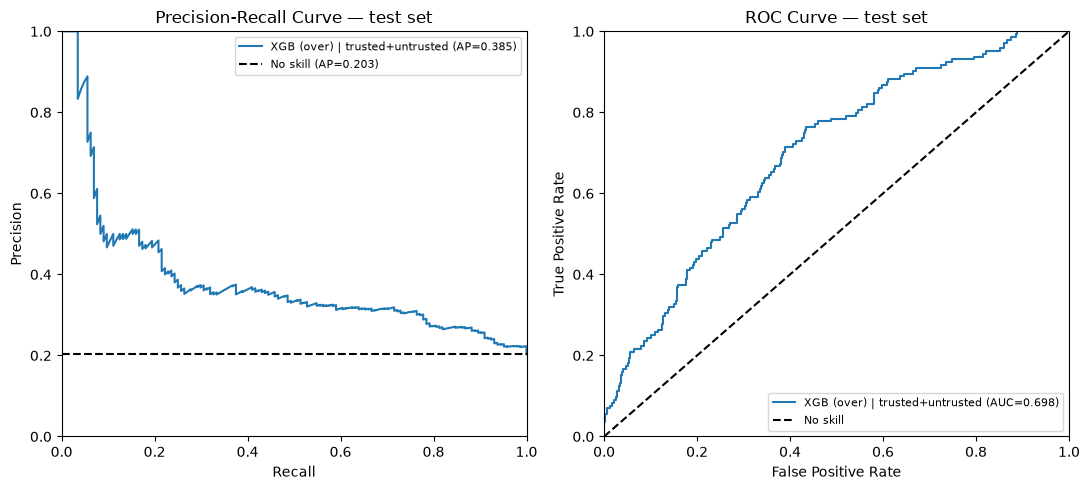

Selected pipeline (by validation PR-AUC): XGB (over) | trusted+untrusted
Test PR-AUC  : 0.3848
Test ROC-AUC : 0.6982
Test F1 (threshold=0.0867, tuned on validation): 0.4046


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

best_combo = val_df.index[0]
best_model_name, best_fs_name = combo_lookup[best_combo]
best_pipe  = pipelines[best_model_name]
X_selected = feature_sets[best_fs_name]

X_train_selected = X_selected.iloc[train_idx]
X_test_selected  = X_selected.iloc[test_idx]

best_pipe.fit(X_train_selected, y_train)          # retrain on full training set
proba_test = best_pipe.predict_proba(X_test_selected)[:, 1]

pr_auc_test  = average_precision_score(y_test, proba_test)
roc_auc_test = roc_auc_score(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)
fpr, tpr, _  = roc_curve(y_test, proba_test)

threshold_test = best_thresholds[best_combo]
y_pred_test = (proba_test >= threshold_test).astype(int)
f1_test = f1_score(y_test, y_pred_test)

positive_rate = y_test.mean()
fig, (ax_pr, ax_roc) = plt.subplots(1, 2, figsize=(11, 5))

ax_pr.plot(rec, prec, label=f'{best_combo} (AP={pr_auc_test:.3f})')
ax_pr.axhline(y=positive_rate, color='k', linestyle='--', label=f'No skill (AP={positive_rate:.3f})')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve — test set')
ax_pr.legend(fontsize=8); ax_pr.set_xlim([0, 1]); ax_pr.set_ylim([0, 1])

ax_roc.plot(fpr, tpr, label=f'{best_combo} (AUC={roc_auc_test:.3f})')
ax_roc.plot([0, 1], [0, 1], 'k--', label='No skill')
ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve — test set')
ax_roc.legend(fontsize=8, loc='lower right'); ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f'Selected pipeline (by validation PR-AUC): {best_combo}')
print(f'Test PR-AUC  : {pr_auc_test:.4f}')
print(f'Test ROC-AUC : {roc_auc_test:.4f}')
print(f'Test F1 (threshold={threshold_test:.4f}, tuned on validation): {f1_test:.4f}')

# 9. Conclusion and Future Research

In this work we investigated comments from the CMV forum.

We created a new and rich dataset with comments, context (thread text by the author of the comment), original post and several features extracted from the comment + context text and from the original post text.

This dataset can be extended in the future by adding more features and can be used for further studies.

Possible features to add:
* Lexical Complexity:
  * Type-token ratio (TTR) – Measures vocabulary richness.
  * Word frequency analysis – Uses external corpora to determine whether a text contains rare or common words.
* Syntactic Complexity:
  * Parse tree depth – Longer, more nested sentences are syntactically complex.
  * Mean length of sentences (MLS) – Longer sentences generally indicate higher complexity.

The dataset can be downloaded from [here](https://drive.google.com/file/d/1cJWCp6StLol6M9yQHdI6irssBkTi-dKO/view?usp=sharing).

We trained multiple ML models to predict persuasiveness and addressed the class imbalance problem by experimenting with undersampling and oversampling (SMOTE) techniques.

Results are reported in the evaluation section above.


# 10. References

1. Priniski, J.H. & Horne, Z. (2018). [Attitude Change on Reddit's Change My View](https://jpriniski.github.io/papers/cogsci-reddit.pdf). In T.T. Rogers, M. Rau, X. Zhu, & C. W. Kalish (Eds.), Proceedings of the 40th Annual Conference of the Cognitive Science Society (pp. 2276-2281). Austin, TX: Cognitive Science Society.

2. [GitHub repo](https://github.com/jpriniski/CMV) of source [1]

3. Xiao, L., Mensah, H. (2022). [How Does the Thread Level of a Comment Affect its Perceived Persuasiveness? A Reddit Study](https://doi.org/10.1007/978-3-031-10464-0_55). In: Arai, K. (eds) Intelligent Computing. SAI 2022. Lecture Notes in Networks and Systems, vol 507. Springer, Cham.

4. Ivan Habernal and Iryna Gurevych. 2016. [What makes a convincing argument? Empirical analysis and detecting attributes of convincingness in Web argumentation](https://aclanthology.org/D16-1129.pdf). In Proceedings of the 2016 Conference on Empirical Methods in Natural Language Processing, pages 1214–1223, Austin, Texas. Association for Computational Linguistics.

## This Work Repo
https://github.com/jct-nlp/change-my-view-2025